# Feature analysis for Pt doped data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, KFold
import shap

In [2]:
# Loading data
data = pd.read_csv('/home/asikainen/Documents/Projects/Doped-TiO2/DFT-and-ML/Calculated-data/Data-for-ML.csv')
data = data.iloc[0:57]
data = data.iloc[:, 1:]

## Pearson correlation matrix

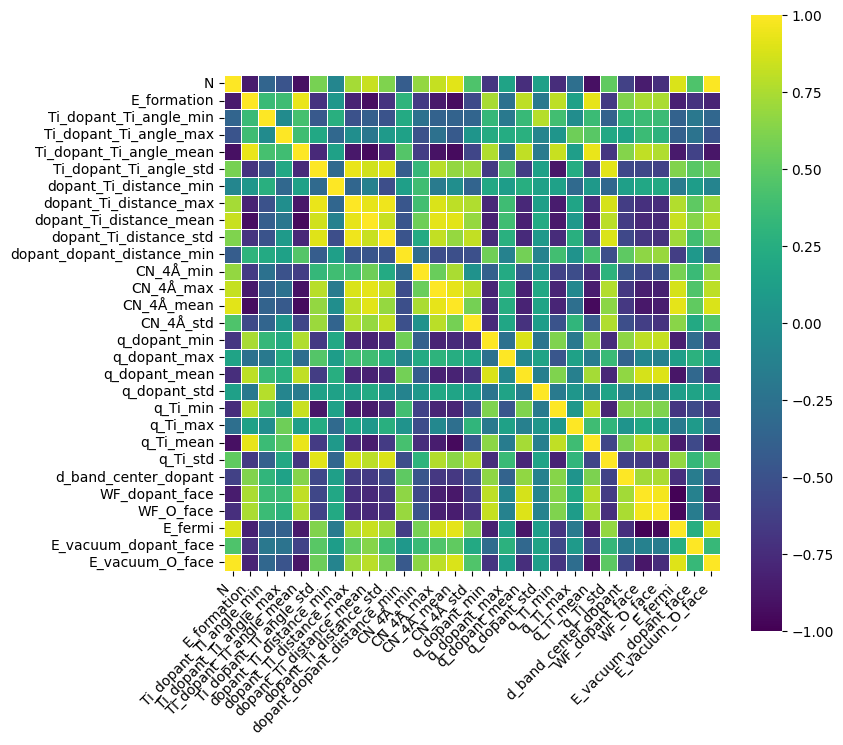

In [3]:
# Correlation matrix
corr_matrix = data.corr()

fig, ax1 = plt.subplots(1, 1, figsize=(8, 8))  

sns.heatmap(corr_matrix, vmin=-1, vmax=1, annot=False, cmap="viridis", linewidths=0.5, square=True, ax=ax1)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

plt.show()

## SHAP analysis

**Calculated using Random forest model** 

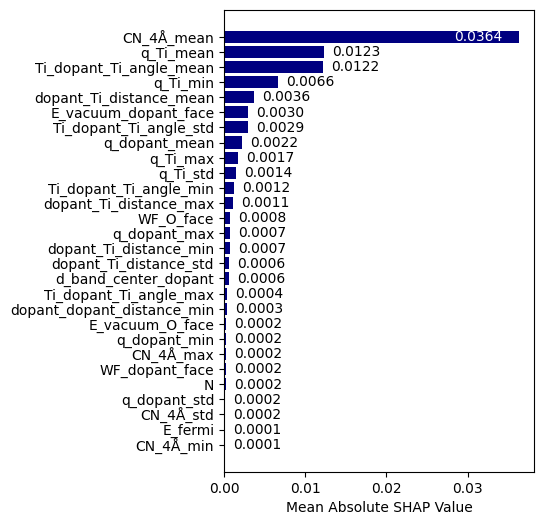

In [4]:
# Variables
yr = data["E_formation"]
Xr = data.drop(columns=["E_formation"])

# Train Random forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(Xr, yr)

# SHAP explainer
explainer = shap.Explainer(model, Xr)
shap_values = explainer(Xr)

# Mean absolute SHAP values
shap_values_abs_mean = np.abs(shap_values.values).mean(axis=0)
feature_ranking = pd.Series(shap_values_abs_mean, index=Xr.columns).sort_values(ascending=False)

# DataFrame for sorting
shap_importance = pd.DataFrame({'Feature': Xr.columns, 'SHAP Value': shap_values_abs_mean})
shap_importance = shap_importance.sort_values(by="SHAP Value", ascending=True) 

# Bar chart 
plt.figure(figsize=(4, 6))
bars = plt.barh(shap_importance['Feature'], shap_importance['SHAP Value'], color='navy')

for i, (bar, value) in enumerate(zip(bars, shap_importance['SHAP Value'])):
    
    # styling
    offset = -0.008 if i == 27 else 0.001
    color = 'white' if i == 27 else 'black'
    
    plt.text(
        value + offset, bar.get_y() + bar.get_height()/2, f"{value:.4f}",                          
        va='center', ha='left', color=color)
    
    plt.xlabel("Mean Absolute SHAP Value")
plt.show()

## Multicollinearity

**Highly correlated pairs were identified, and in each pair the feature with the lower SHAP importance was removed**

In [6]:
# Remove target from the Pearson matrix
features = data.drop(columns=['E_formation'])

# Pearson correlation matrix 
corr_matrix_features = features.corr()

# Highly correlated pairs (|corr| > threshold)
threshold = 0.9
upper = corr_matrix_features.where(np.triu(np.ones(corr_matrix_features.shape), k=1).astype(bool))
high_corr = [(col, row, upper.loc[row, col])
             for col in upper.columns
             for row in upper.index
             if pd.notnull(upper.loc[row, col]) and abs(upper.loc[row, col]) > threshold]

if len(high_corr) == 0:
    print("No highly correlated features found.")
else:
    print("Highly correlated feature pairs (|corr| > 0.9):")
    for f1, f2, val in high_corr:
        print(f"{f1} ↔ {f2}: {val:.2f}")

# Mean absolute SHAP value
shap_importance = pd.Series(np.abs(shap_values.values).mean(axis=0),index=Xr.columns).sort_values(ascending=False)

# Remove one of the features
features_to_drop = set()

for f1, f2, _ in high_corr:
    if shap_importance[f1] < shap_importance[f2]:
        features_to_drop.add(f1)
    else:
        features_to_drop.add(f2)

print("\nFeatures removed due to multicollinearity:")
print(list(features_to_drop))

# Remaining features
screened_features = [f for f in Xr.columns if f not in features_to_drop]
Xr_screened = Xr[screened_features]

print("\nFinal screened feature set:")
print(screened_features)


Highly correlated feature pairs (|corr| > 0.9):
Ti_dopant_Ti_angle_mean ↔ N: -0.92
dopant_Ti_distance_max ↔ Ti_dopant_Ti_angle_std: 0.94
dopant_Ti_distance_mean ↔ Ti_dopant_Ti_angle_mean: -0.95
dopant_Ti_distance_mean ↔ dopant_Ti_distance_max: 0.93
dopant_Ti_distance_std ↔ Ti_dopant_Ti_angle_std: 0.90
dopant_Ti_distance_std ↔ dopant_Ti_distance_max: 0.95
CN_4Å_max ↔ dopant_Ti_distance_mean: 0.92
CN_4Å_mean ↔ N: 0.91
CN_4Å_mean ↔ Ti_dopant_Ti_angle_mean: -0.94
CN_4Å_mean ↔ dopant_Ti_distance_mean: 0.91
CN_4Å_mean ↔ CN_4Å_max: 0.93
q_Ti_mean ↔ N: -0.91
q_Ti_mean ↔ Ti_dopant_Ti_angle_mean: 0.94
q_Ti_mean ↔ CN_4Å_mean: -0.95
q_Ti_std ↔ Ti_dopant_Ti_angle_std: 0.91
WF_O_face ↔ WF_dopant_face: 0.96
E_fermi ↔ CN_4Å_mean: 0.91
E_fermi ↔ WF_dopant_face: -0.99
E_fermi ↔ WF_O_face: -0.96
E_vacuum_O_face ↔ N: 0.99
E_vacuum_O_face ↔ E_fermi: 0.90

Features removed due to multicollinearity:
['CN_4Å_max', 'dopant_Ti_distance_max', 'N', 'Ti_dopant_Ti_angle_mean', 'q_Ti_mean', 'WF_dopant_face', 'dopant

# Recursive feature elimination

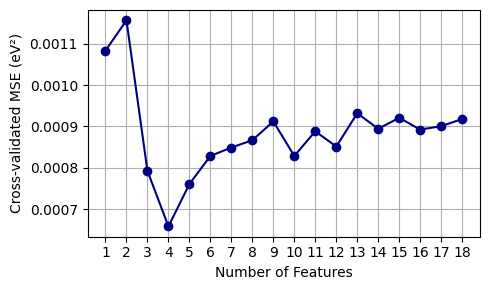

Optimal number of features = 4
Selected features:
['CN_4Å_mean', 'q_Ti_min', 'E_vacuum_dopant_face', 'Ti_dopant_Ti_angle_std']


In [7]:
kf = KFold(n_splits=5, shuffle=True, random_state=0)
mse_scores = []

# Rank only remaining features
shap_importance_screened = shap_importance[screened_features].sort_values(ascending=False)
feature_ranking = shap_importance_screened

# Recursive testing
for k in range(1, len(feature_ranking) + 1):
    relevant_features = feature_ranking.index[:k]

    X_sub = Xr_screened[relevant_features]

    mse = -cross_val_score(model, X_sub, yr, scoring='neg_mean_squared_error', cv=kf).mean()
    mse_scores.append(mse)

# Plot
plt.figure(figsize=(5, 3))
plt.plot(range(1, len(feature_ranking)+1), mse_scores, marker='o', color="navy")
plt.xlabel("Number of Features")
plt.ylabel("Cross-validated MSE (eV²)")
plt.grid(True)
plt.xticks(range(1, len(feature_ranking)+1))
plt.tight_layout()
plt.show()

# Optimal number of feature s
optimal_k = np.argmin(mse_scores) + 1
print(f"Optimal number of features = {optimal_k}")
print("Selected features:")
print(feature_ranking.index[:optimal_k].tolist())
